In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import math

# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
from pyfmreader import loadfile

import plotly.graph_objects as go
import plotly.io as pio

import pandas as pd
import seaborn as sns

pi = math.pi
from pyfmreader.ps_nex.parseTDMS import grab_tdms, parse_tdms

# Add scripts to path
scripts_dir = os.path.abspath('../scripts')
if scripts_dir not in sys.path:
    
    sys.path.insert(0, scripts_dir)


import tether_script as tether
from scipy.stats import linregress



# from pyfmrheo.utils.force_curves import get_poc_RoV_method, get_poc_regulaFalsi_method, correct_tilt, correct_offset
 

In [2]:
filename = '/Volumes/PROJECTS_U1325/Data_sharing/Arkaitz/FS daudi F4/02122025/Canti C#/cell3_0.5ums_0.1s-data-2025.12.02-15.10.44.819.jpk-force-map'


In [3]:

# Define parameters
params = {
    'sav_window_length': 10,
    'sav_polyorder': 1,
    'pl_threshold': 150e-9,
    'pl_min_width': 2,
    'last_num_plateaus': 7,
}

# # Use the function
# results = process_single_file(first_file, params)

# print(f"Found {len(plateaus)} plateaus")
# print(df_plat)

In [4]:
print (f'filename: {filename}')

filename: /Volumes/PROJECTS_U1325/Data_sharing/Arkaitz/FS daudi F4/02122025/Canti C#/cell3_0.5ums_0.1s-data-2025.12.02-15.10.44.819.jpk-force-map


In [5]:
# Load file
try: 
    file = loadfile(filename, hs3_bool=False)
except Exception as e:
    print (f'Error: {e}')
    print(" Could not load file, will try hs3 format...")
    file = loadfile(filename, hs3_bool=True)
    # return None

# Get file metadata
filemetadata = file.filemetadata
height_channel_key = filemetadata['height_channel_key']

# Check if custom calibration is enabled
use_custom_calibration = True

if use_custom_calibration:
    # Use custom calibration values from parameters
    K = params.get('spring_const_Nbym', 0.05)  # N/m
    file_deflection_sensitivity = params.get('defl_sens_nmbyV', 50.0)  # nm/V
    defl_sens = file_deflection_sensitivity / 1e9  # m/V
else:
    # Use calibration values from file metadata
    file_deflection_sensitivity = filemetadata['defl_sens_nmbyV']  # nm/V
    K = filemetadata['spring_const_Nbym']  # N/m
    defl_sens = file_deflection_sensitivity / 1e9  # m/V

# Get force curve with parameters from GUI
# z_sensor_delay = params.get('z_sensor_delay', 0.001)
# bool_correct_overshoot = params.get('bool_correct_overshoot', True)
force_curve = file.getcurve(0)
force_curve.preprocess_force_curve(defl_sens, height_channel_key)

# Get segments
# segs = force_curve.get_segments()
# final_nb_points = filemetadata['final_nb_points']
# relative_SR = filemetadata['relative_sr']

# Extract retract segment data
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        pass  # We only need retract data for this analysis
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = np.flip(-segment.vdeflection * K)
        time_ret = segment.time
        # relative_SR_ret = relative_SR[segid]
        vel_ret_um_s = segment.velocity * 1e06  # Convert from nm to um/s
        # time_ret = np.arange(len(ret_piezo)) * relative_SR_ret 

print (f'Calibration: K: {K} N/m, defl_sens: {defl_sens} m/V')
# print (f'relative_Sr: {relative_SR_ret}, segment_velocity in um/s: {vel_ret_um_s}')

Calibration: K: 0.05 N/m, defl_sens: 5e-08 m/V


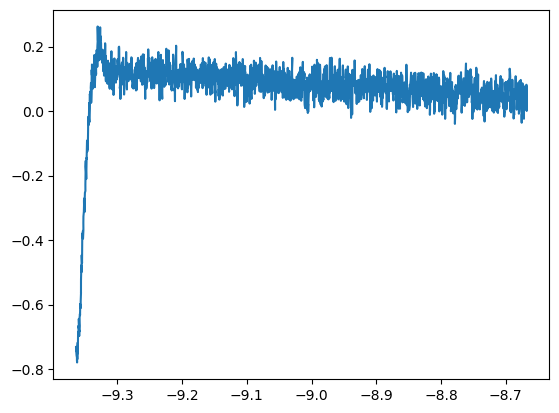

In [280]:
plt.plot(ret_piezo*1e6, ret_deflection*1e9)

In [281]:
# Tilt correction
max_offset = params.get('max_offset', 70)  # %
min_offset = params.get('min_offset', 60)   # %
max_offset, min_offset = tether.update_tilt_range(ret_piezo, max_offset, min_offset, offset_type='percentage')

tilt = False

if tilt :
    tilt_ret_deflection_N = tether.correct_tilt(ret_piezo, ret_deflection, max_offset, min_offset)
else :
    tilt_ret_deflection_N = ret_deflection


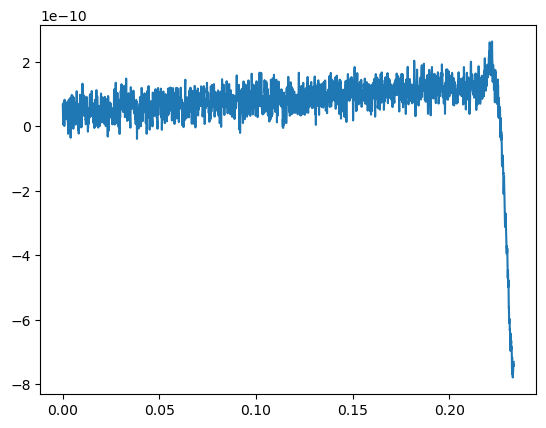

In [282]:
plt.plot(time_ret, tilt_ret_deflection_N)

In [283]:
velocity_calc = -tether.calculate_velocity(ret_piezo, time_ret)  # µm/s

print(f'calculated_velocity: {velocity_calc} µm/s')

# Find contact point 
index_first_positive = tether.find_first_positive(tilt_ret_deflection_N)
first_positive_displacement = ret_piezo[index_first_positive]
ret_corrected_displacement = ret_piezo - first_positive_displacement

print (f'First positive index: {index_first_positive}, First positive displacement: {first_positive_displacement}')
print (f'force at first positive index: {tilt_ret_deflection_N[index_first_positive]} N')

# Apply Savitzky-Golay smoothing in force curve
savitz_defl = tether.savitzky_golay_smooth(tilt_ret_deflection_N, window_length=5, polyorder=1)

# Extract data after contact point
defl_savitz = savitz_defl[index_first_positive:]
displacement = ret_corrected_displacement[index_first_positive:]
# rel_time = np.arange(len(displacement)) * relative_SR_ret



calculated_velocity: -3.0020812042296448 µm/s
First positive index: 0, First positive displacement: -8.667776891888288e-06
force at first positive index: 6.630074450885149e-11 N


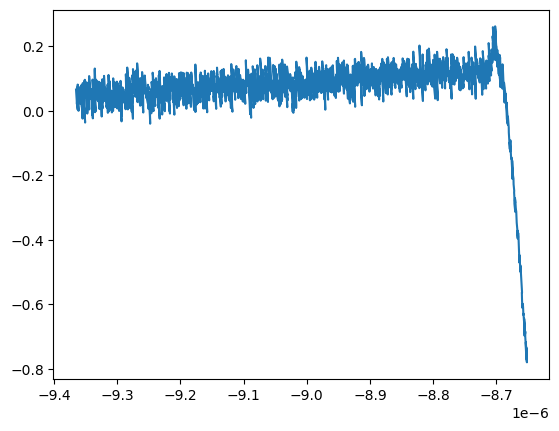

In [284]:
POC = [first_positive_displacement, 0.0]
force_curve.get_force_vs_indentation(POC, K)

plt.figure()
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        pass  # We only need retract data for this analysis
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.indentation
        ret_deflection = -segment.force
        time_ret = segment.time
        plt.plot(ret_piezo - first_positive_displacement, ret_deflection*1e9, label=f'Segment {segid}')

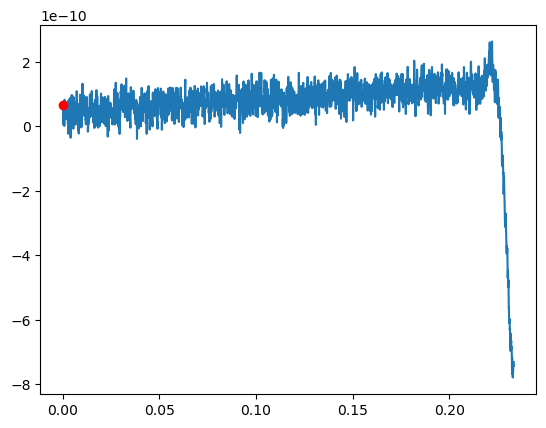

In [285]:
plt.plot(time_ret, tilt_ret_deflection_N)
# plot index first positive as point
plt.plot(time_ret[index_first_positive], tilt_ret_deflection_N[index_first_positive], 'ro')

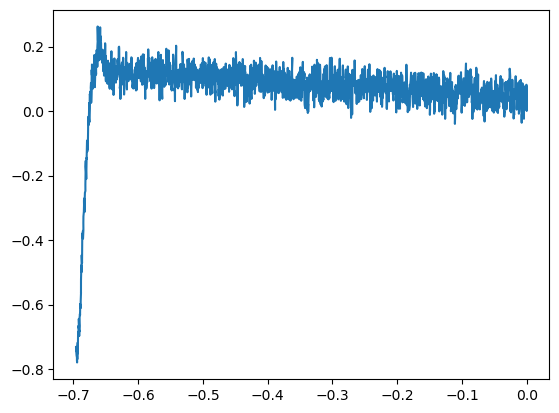

In [286]:
plt.plot(ret_corrected_displacement*1e6, tilt_ret_deflection_N*1e9)

In [287]:
print (f'diplacement: {displacement[-5:]}, \n deflection: {defl_savitz[-5:]}, \nparams: {params}')

diplacement: [-6.95123427e-07 -6.95409057e-07 -6.95464495e-07 -6.95805367e-07
 -6.95919614e-07], 
 deflection: [-7.56564797e-10 -7.50912975e-10 -7.44265354e-10 -7.38710719e-10
 -7.33156084e-10], 
params: {'sav_window_length': 10, 'sav_polyorder': 1, 'pl_threshold': 1.5e-07, 'pl_min_width': 2, 'last_num_plateaus': 7}


In [288]:
    # add case structure to choose what method used for analysis
# Find plateaus
# plateaus, df_plat, df_data, velocity_calc_um_s = tether.find_plateaus(displacement, defl_savitz, params, dt=relative_SR_ret)

In [289]:
x = displacement.copy()
y = defl_savitz.copy()
dt = time_ret[1] - time_ret[0]
print (f'len(x): {len(x)}, len(y): {len(y)}, dt: {dt}')

len(x): 3500, len(y): 3500, dt: 6.666666666666666e-05


In [290]:
# Define default parameters
default_params = {
    'sav_window_length': 10,
    'sav_polyorder': 1,
    
    'pl_threshold': 0.01,
    'pl_min_width': 2,
    'pl_min_width_um': 2,

    'last_num_plateaus': 7,
    'last_plateau_avg_percentage': 15,  # New parameter: percentage of last plateau to average
}

In [291]:
debug = True
# Merge with input params
if params is None:
    params = {}
final_params = {**default_params, **params}

# Calculate spacing for time array
dt_arr = np.arange(len(y)) * dt

# calculate dx of displacement
dx =np.abs(x[-3] - x[-4])
if dx ==0:
    # shift to the left to calculate dx
    dx = np.abs(x[-2] - x[-1])
    print (dx)

if dx == 0: 
    #shift to the left 
    dx = np.abs(x[-3] - x[-4])

if debug:
    print(f'Pl_threshold: {final_params["pl_threshold"]:.2e} N')
    print(f'total distance: {dx * len(y):.6e} m, dx: {dx:.6e} m')

    print (f'dx:{dx}, dy: {len(y)}')


print (f'len(x): {len(x)}, len(y): {len(y)}, dt: {dt}')


Pl_threshold: 1.50e-07 N
total distance: 1.940314e-07 m, dx: 5.543754e-11 m
dx:5.543753918076132e-11, dy: 3500
len(x): 3500, len(y): 3500, dt: 6.666666666666666e-05


In [292]:

# Calculate velocity from displacement vs time
velocity_um_s = -(tether.calculate_velocity(x, dt_arr))

if debug:
    print (f'velocity: {velocity_um_s:.4e} m/s, dt: {dt:.4e} sec')

# Find index of maximum deflection in the whole first half of the force curve
# idx_max = np.argmax(y[:len(y) // 2])
idx_max = np.argmax(y[:len(y)])
if debug:
    print(f"Index of maximum deflection: {idx_max}, value: {y[idx_max]:.4e}")

dt_rel = dt_arr * velocity_um_s
if debug:
    print (f'derivative_dt = {dt_rel[-1]:0.4g} µm, relative_dt = {dt:0.4g}')

# Calculate derivative of deflection with respect to time
dy = np.gradient(y, dt_rel)
dy_smooth = np.abs(dy)
dy_abs_sav = tether.savitzky_golay_smooth(
    dy_smooth,
    window_length=final_params['sav_window_length'], 
    polyorder=final_params['sav_polyorder']
)

# Convert pl_min_width_um to number of points
# sampling_rate = 1 / dt  # Hz
velocity_m_s = velocity_um_s * 1e-06  # Convert µm/s to m/s
distance_per_point = velocity_m_s * dt  # meters per data point
pl_min_width_points = int(final_params['pl_min_width_um'] * 1e-6 / distance_per_point)
# Print the actual physical distance covered by the minimum plateau width (in µm)
actual_distance_um = pl_min_width_points * distance_per_point * 1e6 

if debug:
    print(f'pl_min_width_points: {pl_min_width_points} points, distance = {actual_distance_um:.2f} µm')
# final_params['pl_min_width'] = pl_min_width_points

# calculate index for params['plateau_end_remove_percent']
pl_end_remove_points = int(len(y) * final_params.get('plateau_end_remove_percent', 0) / 100.0)

# Truncate data arrays ONLY for plateau detection
if pl_end_remove_points == 0:
    # Don't remove anything - use entire arrays for plateau detection
    y_analysis = y.copy()
    x_analysis = x.copy()
    dy_abs_sav_analysis = dy_abs_sav
    print(f'Using full arrays for plateau detection. Length: {len(y_analysis)}')
else:
    # Remove the specified percentage from the end for plateau detection ONLY
    end_idx = len(y) - pl_end_remove_points
    y_analysis = y[:end_idx]
    x_analysis = x[:end_idx]
    dy_abs_sav_analysis = dy_abs_sav[:end_idx]

    if debug:
        print(f'Removing {pl_end_remove_points} points ({final_params.get("plateau_end_remove_percent", 0)}%) from end for plateau detection. Analysis length: {len(y_analysis)}/{len(y)}')

# Find flat plateaus using truncated data
is_flat = dy_abs_sav_analysis < final_params['pl_threshold']

plateaus = []
ruptures = []
start = None

for i, flat in enumerate(is_flat):
    if flat and start is None:
        start = i
    elif not flat and start is not None:
        if i - start >= pl_min_width_points:
            plateaus.append((start, i))
        start = None

# Check for plateau at the end (use length of analysis arrays, not original)
if start is not None and len(y_analysis) - start >= pl_min_width_points:
    plateaus.append((start, len(y_analysis)))

print(f'Raw plateaus found: {len(plateaus)}')

# Keep only the last N plateaus
if final_params['last_num_plateaus'] == -1:
    # plot all plateaus
    plateaus = plateaus[:]
else:
    # plot only the last N plateaus
    plateaus = plateaus[-final_params['last_num_plateaus']:]

if debug:
    print(f'Plateaus after filtering (last {final_params["last_num_plateaus"]}): {len(plateaus)}')

# get the index of detachment which is between plateaus
# Get the end index of the first plateau and the start index of the next plateau (if available)
if len(plateaus) >= 2:
    for i in range(len(plateaus) - 1):
        first_plateau_end = plateaus[i][1]
        next_plateau_start = plateaus[i + 1][0]
        ruptures.append((first_plateau_end, next_plateau_start))
else:
    ruptures.append((None, None))

# calculate ruptures slope
rupture_slopes = []
for start, end in ruptures:
    if start is not None and end is not None:
        x_slice = x_analysis[start:end]
        y_slice = y_analysis[start:end]
        if end - start > 1 and len(np.unique(x_slice)) > 1:
            slope, _, _, _, _ = np.linregress(x_slice, y_slice)
            rupture_slopes.append(slope)
        else:
            rupture_slopes.append(np.nan)

#%%% Calculate plateau statistics %%%#
plateau_avg_idx_arr = []
plateau_delta_avg_arr = []
plateau_start_n_1_arr = []

# Initialize variables that might be referenced later (handle case when no plateaus found)
plateau_start_n_1 = 0
start_n_1 = 0
percentage_n_1 = 25.0 / 100.0  # Default value

for i, (start, end) in enumerate(plateaus):
    # added params for calculating the last 25% of the N-1 plateau. 
    # print (f'start_n_1: {start_n_1}, start: {start},  end: {end}, length: {plateau_index_length}, plateau_start_n_1: {plateau_start_n_1}')
    final_params['N-1_plateau_percentage'] = 25
    percentage_n_1 = final_params['N-1_plateau_percentage'] / 100.0

    plateau_index_length = end - start
    plateau_start_n_1 = int(np.floor((plateau_index_length * percentage_n_1)))

    start_n_1 = end - plateau_start_n_1
    plateau_avg_index = int((end - start) / 2)

    # Special handling for the last plateau average calculation
    if i == len(plateaus) - 1:
        # For the last plateau, use only a percentage of the plateau for averaging
        percentage = final_params['last_plateau_avg_percentage'] / 100.0
        
        plateau_length = end - start
        avg_length = max(plateau_avg_index, int(plateau_length * percentage))  # Ensure at least 1 point
        # print (f'avg_length: {avg_length}')
        
        # Take the first X% of the last plateau
        avg_end = start + avg_length
        plateau_avg = np.mean(y_analysis[start:avg_end])
        plateau_avg_idx = start + np.argmin(np.abs(y_analysis[start:avg_end] - plateau_avg))
        
        # Use start - 1 for the index array (maintaining existing behavior)
        plateau_avg_idx_arr.append(start - 1)
    else:
        # For all other plateaus, use the full plateau for averaging
        plateau_avg = np.mean(y_analysis[start:end])
        plateau_avg_idx = start + np.argmin(np.abs(y_analysis[start:end] - plateau_avg))
        plateau_avg_idx_arr.append(plateau_avg_idx)
    
    # Calculate delta differences from the perspective of going backwards
    if i < len(plateaus) - 1:

        current_avg = np.mean(y_analysis[start_n_1:end])
        next_avg = np.mean(y_analysis[plateaus[i+1][0]:plateaus[i+1][1]])


        delta = current_avg - next_avg  # Difference to next plateau
        plateau_delta_avg_arr.append(delta)
        plateau_start_n_1_arr.append(start_n_1)
    else:
        # For the last plateau, there's no next plateau to compare
        plateau_delta_avg_arr.append(0.0)  # or np.nan if you prefer
        
# Calculate plateau derivatives
plateau_derivatives = []
for start, end in plateaus:
    plateau_derivative = np.mean(np.abs(dy_abs_sav_analysis[start:end]))
    plateau_derivatives.append(plateau_derivative)

# calculate slope of plateau
plateau_slopes = []
for start, end in plateaus:
    plateau_index_length = end - start
    plateau_start_n_1 = int(np.floor((plateau_index_length * percentage_n_1)))
    start_n_1 = end - plateau_start_n_1

    if plateau_index_length > 3 and len(np.unique(x_analysis[start_n_1:end])) > 1:
        x_slice = x_analysis[start_n_1:end]
        y_slice = y_analysis[start_n_1:end]
        # check if there are only two points, that they are not the same, if so, 
        # added negative because the retract is flipped along the horizontal axis
    else:
        x_slice = x_analysis[start:end]
        y_slice = y_analysis[start:end]

    if len(x_slice) > 1 and len(np.unique(x_slice)) > 1:
        slope, _, _, _, _ = linregress(x_slice, y_slice)
        if slope == 0:
            plateau_slopes.append(np.nan)
        else:
            plateau_slopes.append(-slope)
    else:
        plateau_slopes.append(np.nan)

#

velocity: -3.0021e+00 m/s, dt: 6.6667e-05 sec
Index of maximum deflection: 3329, value: 2.4291e-10
derivative_dt = -0.7003 µm, relative_dt = 6.667e-05
pl_min_width_points: -9993 points, distance = 2.00 µm
Using full arrays for plateau detection. Length: 3500
Raw plateaus found: 1
Plateaus after filtering (last 7): 1


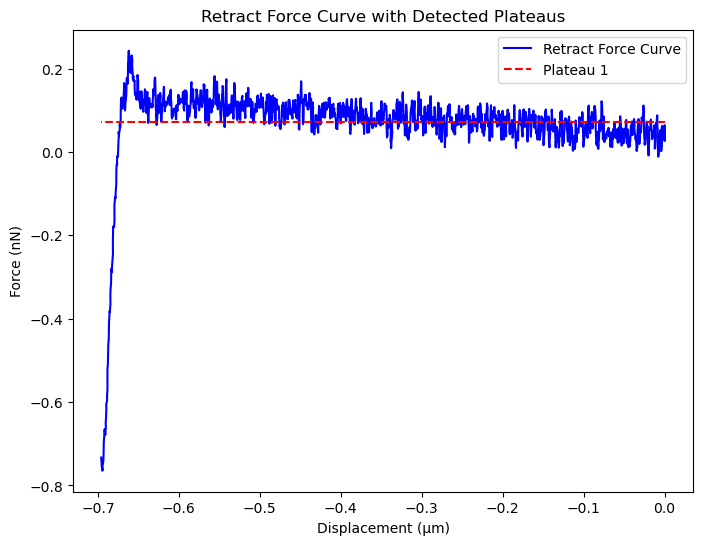

In [293]:
# plot plateaus on top of retract force curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x * 1e6, y * 1e9, label='Retract Force Curve', color='blue')
# --- IGNORE ---
for i, (start, end) in enumerate(plateaus):
    ax.hlines(
        y=np.mean(y[start:end]) * 1e9,
        xmin=x[start] * 1e6,
        xmax=x[end - 1] * 1e6,
        colors='red',
        linestyles='dashed',
        label=f'Plateau {i + 1}' if i == 0 else "",
    )
# --- IGNORE ---
ax.set_xlabel('Displacement (µm)')
ax.set_ylabel('Force (nN)')
ax.set_title('Retract Force Curve with Detected Plateaus')
ax.legend()
plt.show()